In [ ]:
#ffffffffffffffffffffffff

In [ ]:
#něco něco jiného

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [63]:
dfs = {}

dfs["CNC"] = pd.read_csv("CNC.csv")
dfs["EQR"] = pd.read_csv("EQR.csv")
dfs["IVZ"] = pd.read_csv("IVZ.csv")
dfs["TRV"] = pd.read_csv("TRV.csv")

# PART 1 Task 1 

In [64]:
for name, df in dfs.items():
    print(name, "sum of adj close not equal close:",(df["Close"] != df["Adj Close"]).sum())
    print(name, "sum of adj close equal close:",(df["Close"] == df["Adj Close"]).sum())
    print()

CNC sum of adj close not equal close: 0
CNC sum of adj close equal close: 1259

EQR sum of adj close not equal close: 1040
EQR sum of adj close equal close: 219

IVZ sum of adj close not equal close: 1071
IVZ sum of adj close equal close: 188

TRV sum of adj close not equal close: 1025
TRV sum of adj close equal close: 234



# PART 1 Task 2

In [65]:
for name, df in dfs.items():
    print(name, "Highest price:", df["Adj Close"].max())
    print(name, "Lowest price:", df["Adj Close"].min())
    print()

CNC Highest price: 97.22000122070312
CNC Lowest price: 42.72999954223633

EQR Highest price: 93.23999786376952
EQR Lowest price: 44.40938949584961

IVZ Highest price: 30.65396881103516
IVZ Lowest price: 6.301447868347168

TRV Highest price: 187.75
TRV Lowest price: 78.2640151977539



In [66]:
for name, df in dfs.items():
    df["log_return"] = np.log(df["Adj Close"] / df["Adj Close"].shift(1))

In [72]:
for name, df in dfs.items():
    df["Date"] = pd.to_datetime(df["Date"])
    df.set_index("Date", inplace=True)
    
    weekly_avg = df["Volume"].resample("W").mean().mean()
    
    print(name, weekly_avg)


KeyError: 'Date'

TypeError: 'DatetimeIndex' object is not callable

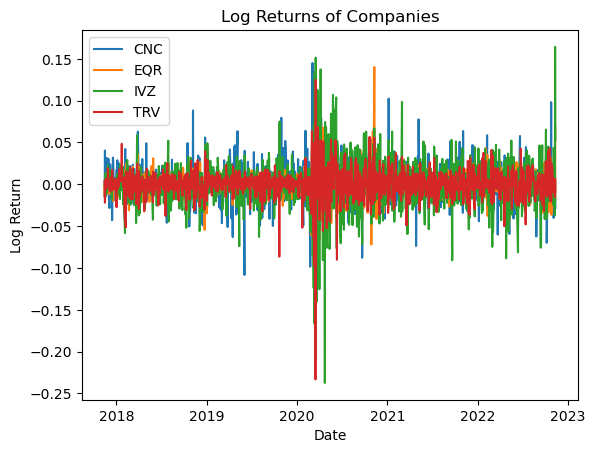

In [76]:
for name, df in dfs.items():
    plt.plot(df.index, df["log_return"], label=name)

plt.legend()
plt.title("Log Returns of Companies")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.show()

In [78]:


for name, df in dfs.items():
    print(name, "total retruns:", df["Adj Close"].iloc[-1]/df["Adj Close"].iloc[0] -1)
    

CNC total retruns: 0.739508248494456
EQR total retruns: 0.03203663092283371
IVZ total retruns: -0.28256850698194824
TRV total retruns: 0.5077122432704555


In [87]:
for name, df in dfs.items():
    df["pct_change"] = df["Adj Close"].pct_change()

In [88]:
dfs

{'CNC':                  High        Low       Open      Close     Volume  Adj Close  \
 Date                                                                           
 2017-11-13  47.494999  46.555000  46.555000  47.180000  3056200.0  47.180000   
 2017-11-14  47.180000  46.375000  46.974998  46.514999  1715400.0  46.514999   
 2017-11-15  46.509998  45.035000  46.400002  46.075001  2552800.0  46.075001   
 2017-11-16  48.465000  46.255001  46.255001  47.970001  3466600.0  47.970001   
 2017-11-17  47.974998  47.520000  47.834999  47.570000  2009200.0  47.570000   
 ...               ...        ...        ...        ...        ...        ...   
 2022-11-07  83.690002  80.910004  82.379997  82.949997  3635700.0  82.949997   
 2022-11-08  84.949997  82.269997  82.830002  84.000000  3830500.0  84.000000   
 2022-11-09  84.849998  83.660004  84.449997  83.879997  3167800.0  83.879997   
 2022-11-10  85.959999  81.690002  85.959999  84.430000  3922800.0  84.430000   
 2022-11-11  84.43000

In [89]:
for name, df in dfs.items():
    df["index (Day 1 = 100)"] = df["Adj Close"]/df["Adj Close"].iloc[0]*100

In [90]:
dfs

{'CNC':                  High        Low       Open      Close     Volume  Adj Close  \
 Date                                                                           
 2017-11-13  47.494999  46.555000  46.555000  47.180000  3056200.0  47.180000   
 2017-11-14  47.180000  46.375000  46.974998  46.514999  1715400.0  46.514999   
 2017-11-15  46.509998  45.035000  46.400002  46.075001  2552800.0  46.075001   
 2017-11-16  48.465000  46.255001  46.255001  47.970001  3466600.0  47.970001   
 2017-11-17  47.974998  47.520000  47.834999  47.570000  2009200.0  47.570000   
 ...               ...        ...        ...        ...        ...        ...   
 2022-11-07  83.690002  80.910004  82.379997  82.949997  3635700.0  82.949997   
 2022-11-08  84.949997  82.269997  82.830002  84.000000  3830500.0  84.000000   
 2022-11-09  84.849998  83.660004  84.449997  83.879997  3167800.0  83.879997   
 2022-11-10  85.959999  81.690002  85.959999  84.430000  3922800.0  84.430000   
 2022-11-11  84.43000

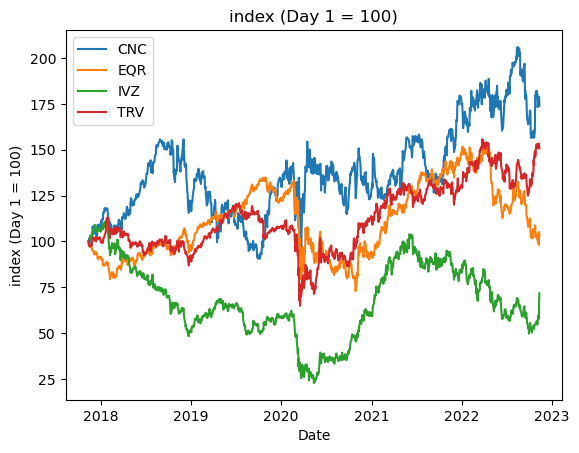

In [91]:
for name, df in dfs.items():
    plt.plot(df.index, df["index (Day 1 = 100)"], label=name)

plt.legend()
plt.title("index (Day 1 = 100)")
plt.xlabel("Date")
plt.ylabel("index (Day 1 = 100)")
plt.show()

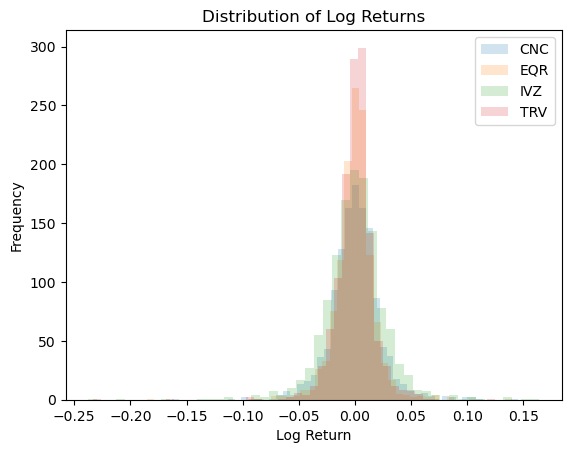

In [93]:
for name, df in dfs.items():
    plt.hist(df["log_return"], bins=50, alpha=0.2, label=name)

plt.legend()
plt.title("Distribution of Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.show()

# TASK 2

In [94]:
df = pd.read_csv("https://ies-python-midterm.s3.eu-central-1.amazonaws.com/companies/companies_no_subindustry.csv")

In [95]:
df

,Symbol,Security,GICS_Sector,hq,included,Founded
0,MMM,3M,Industrials,"Saint Paul, Minnesota",09.08.1976,1902
1,AOS,A. O. Smith,Industrials,"Milwaukee, Wisconsin",26.07.2017,1916
2,ABT,Abbott,Health Care,"North Chicago, Illinois",31.03.1964,1888
3,ABBV,AbbVie,Health Care,"North Chicago, Illinois",31.12.2012,2013 (1888)
4,ABMD,Abiomed,Health Care,"Danvers, Massachusetts",31.05.2018,1981
...,...,...,...,...,...,...
498,YUM,Yum! Brands,Consumer Discretionary,"Louisville, Kentucky",06.10.1997,1997
499,ZBRA,Zebra Technologies,Information Technology,"Lincolnshire, Illinois",23.12.2019,1969
500,ZBH,Zimmer Biomet,Health Care,"Warsaw, Indiana",07.08.2001,1927
501,ZION,Zions Bancorporation,Financials,"Salt Lake City, Utah",22.06.2001,1873


In [102]:
df["included"].isna().sum()

np.int64(45)

Df has 45 valueues without inclusion date.

In [106]:
df = df.drop(df[df["included"].isna()].index)

In [118]:
df["included"] = pd.to_datetime(df["included"], dayfirst=True, errors="coerce")

In [119]:
df

,Symbol,Security,GICS_Sector,hq,included,Founded
0,MMM,3M,Industrials,"Saint Paul, Minnesota",1976-08-09,1902
1,AOS,A. O. Smith,Industrials,"Milwaukee, Wisconsin",2017-07-26,1916
2,ABT,Abbott,Health Care,"North Chicago, Illinois",1964-03-31,1888
3,ABBV,AbbVie,Health Care,"North Chicago, Illinois",2012-12-31,2013 (1888)
4,ABMD,Abiomed,Health Care,"Danvers, Massachusetts",2018-05-31,1981
...,...,...,...,...,...,...
498,YUM,Yum! Brands,Consumer Discretionary,"Louisville, Kentucky",1997-10-06,1997
499,ZBRA,Zebra Technologies,Information Technology,"Lincolnshire, Illinois",2019-12-23,1969
500,ZBH,Zimmer Biomet,Health Care,"Warsaw, Indiana",2001-08-07,1927
501,ZION,Zions Bancorporation,Financials,"Salt Lake City, Utah",2001-06-22,1873


In [122]:
print(df["included"].max())
df["Symbol"][df["included"].idxmax()]

2022-11-01 00:00:00


'ACGL'

In [123]:
print(df["included"].min())
df["Symbol"][df["included"].idxmin()]

1957-03-04 00:00:00


'MO'

In [145]:
(pd.Timestamp.now() - df["included"].mean()

Timedelta('24 days 20:41:00.796941221')

In [143]:
df["age_years"] = (pd.Timestamp.now() - df["included"]).dt.days / 365
df["age_years"].mean()

np.float64(24.85945506548246)

In [129]:
df["GICS_Sector"].unique()

array(['Industrials', 'Health Care', 'Information Technology',
       'Communication Services', 'Consumer Staples',
       'Consumer Discretionary', 'Utilities', 'Financials', 'Materials',
       'Real Estate', 'Energy'], dtype=object)

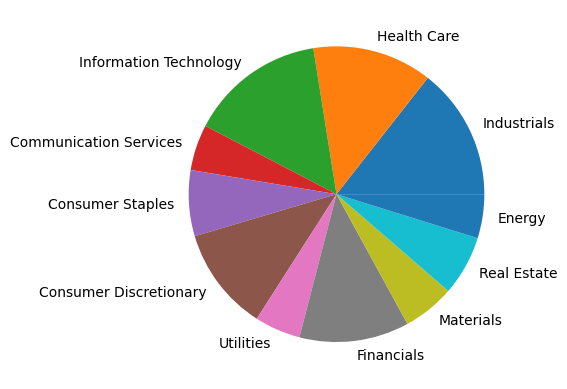

In [137]:
y = []

for i in df["GICS_Sector"].unique():
    y.append((df["GICS_Sector"] == i).sum())
    

plt.pie(y, labels = df["GICS_Sector"].unique())
plt.show()

ValueError: No axis named Industrials for object type Series

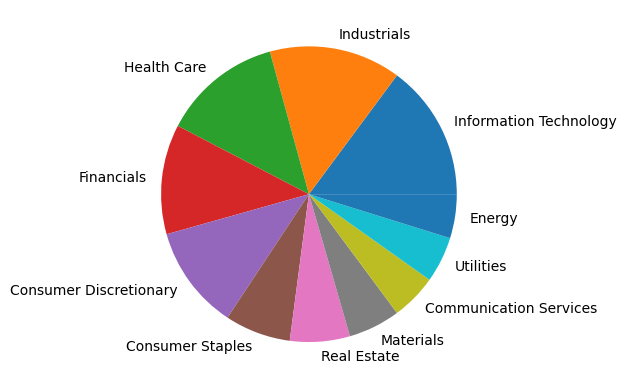

In [138]:
counts = df["GICS_Sector"].value_counts()

plt.pie(counts, labels=counts.index)
plt.show()

In [139]:
counts

GICS_Sector
Information Technology    68
Industrials               66
Health Care               60
Financials                55
Consumer Discretionary    52
Consumer Staples          33
Real Estate               30
Materials                 26
Communication Services    23
Utilities                 23
Energy                    22
Name: count, dtype: int64

In [146]:
df

,Symbol,Security,GICS_Sector,hq,included,Founded,age_years
0,MMM,3M,Industrials,"Saint Paul, Minnesota",1976-08-09,1902,49.706849
1,AOS,A. O. Smith,Industrials,"Milwaukee, Wisconsin",2017-07-26,1916,8.717808
2,ABT,Abbott,Health Care,"North Chicago, Illinois",1964-03-31,1888,62.073973
3,ABBV,AbbVie,Health Care,"North Chicago, Illinois",2012-12-31,2013 (1888),13.287671
4,ABMD,Abiomed,Health Care,"Danvers, Massachusetts",2018-05-31,1981,7.871233
...,...,...,...,...,...,...,...
498,YUM,Yum! Brands,Consumer Discretionary,"Louisville, Kentucky",1997-10-06,1997,28.534247
499,ZBRA,Zebra Technologies,Information Technology,"Lincolnshire, Illinois",2019-12-23,1969,6.306849
500,ZBH,Zimmer Biomet,Health Care,"Warsaw, Indiana",2001-08-07,1927,24.695890
501,ZION,Zions Bancorporation,Financials,"Salt Lake City, Utah",2001-06-22,1873,24.821918


In [147]:
df["state"] = df["hq"].str.split(",").str[1]

df

,Symbol,Security,GICS_Sector,hq,included,Founded,age_years,state
0,MMM,3M,Industrials,"Saint Paul, Minnesota",1976-08-09,1902,49.706849,Minnesota
1,AOS,A. O. Smith,Industrials,"Milwaukee, Wisconsin",2017-07-26,1916,8.717808,Wisconsin
2,ABT,Abbott,Health Care,"North Chicago, Illinois",1964-03-31,1888,62.073973,Illinois
3,ABBV,AbbVie,Health Care,"North Chicago, Illinois",2012-12-31,2013 (1888),13.287671,Illinois
4,ABMD,Abiomed,Health Care,"Danvers, Massachusetts",2018-05-31,1981,7.871233,Massachusetts
...,...,...,...,...,...,...,...,...
498,YUM,Yum! Brands,Consumer Discretionary,"Louisville, Kentucky",1997-10-06,1997,28.534247,Kentucky
499,ZBRA,Zebra Technologies,Information Technology,"Lincolnshire, Illinois",2019-12-23,1969,6.306849,Illinois
500,ZBH,Zimmer Biomet,Health Care,"Warsaw, Indiana",2001-08-07,1927,24.695890,Indiana
501,ZION,Zions Bancorporation,Financials,"Salt Lake City, Utah",2001-06-22,1873,24.821918,Utah


In [151]:
df["state"].value_counts()

state
 California                    65
 New York                      44
 Texas                         41
 Illinois                      31
 Massachusetts                 18
 Pennsylvania                  18
 Ohio                          17
 North Carolina                16
 Georgia                       16
 New Jersey                    15
 Virginia                      15
 Florida                       14
 Connecticut                   13
 Minnesota                     13
 Washington                    12
 Michigan                      10
 Ireland                        7
 Tennessee                      7
 Colorado                       7
 Wisconsin                      6
 Missouri                       6
 Indiana                        6
 Arizona                        5
 Maryland                       5
 Nevada                         4
 Rhode Island                   4
 Oklahoma                       4
 Louisiana                      3
 Arkansas                       3
 United 

In [153]:
subindustry = pd.read_csv("https://ies-python-midterm.s3.eu-central-1.amazonaws.com/companies/companies_subindustry.csv")

In [155]:
subindustry.set_index("Symbol", inplace=True)

subindustry

,subindustry
Symbol,
MMM,Industrial Conglomerates
AOS,Building Products
ABT,Health Care Equipment
ABBV,Pharmaceuticals
ABMD,Health Care Equipment
...,...
YUM,Restaurants
ZBRA,Electronic Equipment & Instruments
ZBH,Health Care Equipment


In [159]:
subindustry["subindustry"]["MMM"]

'Industrial Conglomerates'

In [165]:
df["subindustry"] = df["Symbol"].map(subindustry["subindustry"])

In [166]:
df

,Symbol,Security,GICS_Sector,hq,included,Founded,age_years,state,subindustry
0,MMM,3M,Industrials,"Saint Paul, Minnesota",1976-08-09,1902,49.706849,Minnesota,Industrial Conglomerates
1,AOS,A. O. Smith,Industrials,"Milwaukee, Wisconsin",2017-07-26,1916,8.717808,Wisconsin,Building Products
2,ABT,Abbott,Health Care,"North Chicago, Illinois",1964-03-31,1888,62.073973,Illinois,Health Care Equipment
3,ABBV,AbbVie,Health Care,"North Chicago, Illinois",2012-12-31,2013 (1888),13.287671,Illinois,Pharmaceuticals
4,ABMD,Abiomed,Health Care,"Danvers, Massachusetts",2018-05-31,1981,7.871233,Massachusetts,Health Care Equipment
...,...,...,...,...,...,...,...,...,...
498,YUM,Yum! Brands,Consumer Discretionary,"Louisville, Kentucky",1997-10-06,1997,28.534247,Kentucky,Restaurants
499,ZBRA,Zebra Technologies,Information Technology,"Lincolnshire, Illinois",2019-12-23,1969,6.306849,Illinois,Electronic Equipment & Instruments
500,ZBH,Zimmer Biomet,Health Care,"Warsaw, Indiana",2001-08-07,1927,24.695890,Indiana,Health Care Equipment
501,ZION,Zions Bancorporation,Financials,"Salt Lake City, Utah",2001-06-22,1873,24.821918,Utah,Regional Banks


In [167]:
pd.merge(df, subindustry, on="Symbol")

,Symbol,Security,GICS_Sector,hq,included,Founded,age_years,state,subindustry_x,subindustry_y
0,MMM,3M,Industrials,"Saint Paul, Minnesota",1976-08-09,1902,49.706849,Minnesota,Industrial Conglomerates,Industrial Conglomerates
1,AOS,A. O. Smith,Industrials,"Milwaukee, Wisconsin",2017-07-26,1916,8.717808,Wisconsin,Building Products,Building Products
2,ABT,Abbott,Health Care,"North Chicago, Illinois",1964-03-31,1888,62.073973,Illinois,Health Care Equipment,Health Care Equipment
3,ABBV,AbbVie,Health Care,"North Chicago, Illinois",2012-12-31,2013 (1888),13.287671,Illinois,Pharmaceuticals,Pharmaceuticals
4,ABMD,Abiomed,Health Care,"Danvers, Massachusetts",2018-05-31,1981,7.871233,Massachusetts,Health Care Equipment,Health Care Equipment
...,...,...,...,...,...,...,...,...,...,...
453,YUM,Yum! Brands,Consumer Discretionary,"Louisville, Kentucky",1997-10-06,1997,28.534247,Kentucky,Restaurants,Restaurants
454,ZBRA,Zebra Technologies,Information Technology,"Lincolnshire, Illinois",2019-12-23,1969,6.306849,Illinois,Electronic Equipment & Instruments,Electronic Equipment & Instruments
455,ZBH,Zimmer Biomet,Health Care,"Warsaw, Indiana",2001-08-07,1927,24.695890,Indiana,Health Care Equipment,Health Care Equipment
456,ZION,Zions Bancorporation,Financials,"Salt Lake City, Utah",2001-06-22,1873,24.821918,Utah,Regional Banks,Regional Banks


In [171]:
cdic = df["subindustry"].value_counts()
cdic

subindustry
Health Care Equipment       18
Industrial Machinery        14
Application Software        13
Packaged Foods & Meats      12
Semiconductors              11
                            ..
Metal & Glass Containers     1
Gas Utilities                1
Water Utilities              1
Agricultural Products        1
Broadcasting                 1
Name: count, Length: 120, dtype: int64

In [180]:
aaaa = df[(df["GICS_Sector"] == "Consumer Discretionary")]["subindustry"].value_counts()

aaaa

subindustry
Specialty Stores                       6
Restaurants                            5
Internet & Direct Marketing Retail     5
Casinos & Gaming                       4
Hotels, Resorts & Cruise Lines         4
Homebuilding                           4
General Merchandise Stores             3
Apparel, Accessories & Luxury Goods    3
Automobile Manufacturers               3
Home Improvement Retail                2
Distributors                           2
Automotive Retail                      2
Auto Parts & Equipment                 2
Apparel Retail                         2
Leisure Products                       1
Consumer Electronics                   1
Computer & Electronics Retail          1
Home Furnishings                       1
Housewares & Specialties               1
Name: count, dtype: int64

<Axes: ylabel='count'>

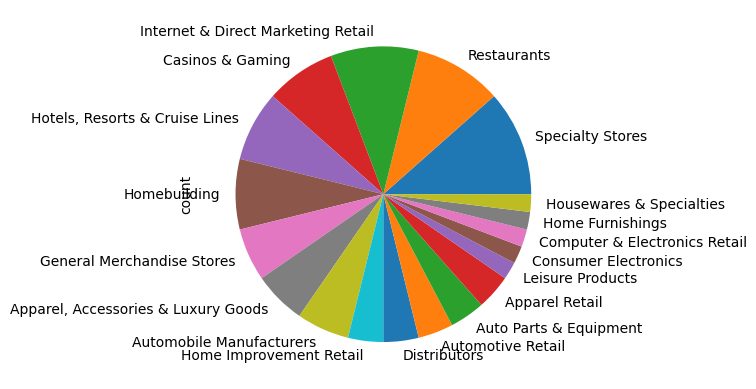

In [182]:
aaaa.plot(kind="pie")